# MSIE Validation — The Two-Axis Double Dissociation
### Companion notebook for *Multi-Scale Information Equilibrium for Robust AI (UVIF)*

This notebook validates the central novel claim of the MSIE framework: that **cross-scale disagreement
$\Delta_{\mathrm{cons}}$ (the resolution axis) is a separable uncertainty signal that detects a failure mode to
which the model-class axis $\mathrm{Var}_{\mathrm{class}}$ — and hence the entire single-axis structural-uncertainty
framework — is structurally blind.**

Three pre-registered results:

| ID | Claim | Section |
|----|-------|---------|
| M1 | **Double dissociation.** $\mathrm{Var}_{\mathrm{class}}$ responds to model-class misspecification ($\delta_{\mathrm{class}}$) and is invariant to scale misspecification; $\Delta_{\mathrm{cons}}$ does the mirror image. | §3 |
| M2 | **Scale-equilibrium recovery.** The held-out error is U-shaped in resolution and minimised at the intrinsic scale; the MSIE equilibrium recovers it. | §4 |
| M3 | **Decision value + regime alarm.** A two-axis policy attains lower decision cost than the class-only (single-axis) policy in the scale-dominated regime where the latter is blind, and reduces to it when no scale misspecification is present. $\bar\Delta_{\mathrm{cons}}$ acts as a window-level regime alarm. | §5 |

Self-contained (NumPy/SciPy/scikit-learn/Matplotlib). All artifacts are written to Google Drive under
`MyDrive/Outputs/MSIE/` (Colab) with a local fallback.

In [1]:
import os, time, datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import rankdata, norm
from sklearn.linear_model import Ridge
import warnings; warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR='/content/drive/MyDrive/Outputs/MSIE'; IN_COLAB=True
except Exception:
    OUTPUT_DIR=os.path.join(os.path.expanduser('~'),'Outputs','MSIE'); IN_COLAB=False
    print('Drive unavailable (not in Colab); local fallback:\n  ',OUTPUT_DIR)
FIG_DIR=os.path.join(OUTPUT_DIR,'Figures'); TABLE_DIR=os.path.join(OUTPUT_DIR,'Tables')
for d in (OUTPUT_DIR,FIG_DIR,TABLE_DIR): os.makedirs(d,exist_ok=True)
_LOG=[]
def log(*a): s=' '.join(str(x) for x in a); print(s); _LOG.append(s)
def save_fig(fig,name):
    for ext in ('png','pdf'): fig.savefig(os.path.join(FIG_DIR,f'{name}.{ext}'),bbox_inches='tight',dpi=200)
    log(f'[figure] Figures/{name}.png,.pdf')
def save_table(df,name,index=True):
    df.to_csv(os.path.join(TABLE_DIR,f'{name}.csv'),index=index); log(f'[table ] Tables/{name}.csv')
plt.rcParams.update({"figure.dpi":110,"font.size":10,"axes.grid":True,"grid.alpha":0.3})
t0=time.time(); log(f'Run {datetime.datetime.now():%Y-%m-%d %H:%M} | {OUTPUT_DIR} | Colab={IN_COLAB}')

Drive unavailable (not in Colab); local fallback:
   /root/Outputs/MSIE
Run 2026-06-18 19:41 | /root/Outputs/MSIE | Colab=False


## 1. Two-axis synthetic environment

The truth combines (i) a **scale-axis** feature — a fine sinusoid of intrinsic frequency $F_0$ whose amplitude
$B=\delta_{\mathrm{scale}}$ controls how much structure lives below the coarse resolutions — and (ii) a
**class-axis** feature — a polynomial in an extrapolation variable $x_2$ whose test-time shift
$\delta_{\mathrm{class}}$ drives heterogeneous model classes to diverge:
$$ g^\star(x) = \tfrac12\sin(2\pi x_1) + \underbrace{B\,\sin(2\pi F_0 x_1)}_{\text{scale axis}}
   + \underbrace{0.8\,x_2 + 0.5\,x_2^2 - 0.3\,x_2^3}_{\text{class axis}} . $$

The **scale** of the representation is the Fourier cutoff $K$ on $x_1$ (coarse $=$ few low frequencies, fine $=$
many): a representation with $K<F_0$ cannot see the fine feature. **Model classes** share an identical band-limited
$x_1$ block and differ only in their basis for the extrapolation variable $x_2$ (polynomial, $\tanh$, piecewise,
clipped, Gaussian) — genuinely heterogeneous inductive biases that capture the $x_1$ feature identically (so the
scale feature does *not* induce class disagreement) but extrapolate differently under $x_2$ shift.

In [2]:
F0=8.0; NOISE=0.15; SCALES_K=[1,2,4,8,16]; SEEDS=4
X2_BASES={
 "poly": lambda x2:[x2,x2**2,x2**3],
 "tanh": lambda x2:[np.tanh(x2),np.tanh(2*x2),np.tanh(0.5*x2)],
 "absln":lambda x2:[x2,np.abs(x2),np.maximum(x2,0.0)],
 "clip": lambda x2:[np.clip(x2,-1,1),np.clip(x2,-2,2),x2],
 "gauss":lambda x2:[x2,np.exp(-x2**2),np.exp(-(x2-1.0)**2)]}
CLASSES=list(X2_BASES.keys()); M,J=len(CLASSES),len(SCALES_K)

def truth(X,B):
    x1,x2=X[:,0],X[:,1]
    return 0.5*np.sin(2*np.pi*x1)+B*np.sin(2*np.pi*F0*x1)+0.8*x2+0.5*x2**2-0.3*x2**3
def sample(n,d_class,B,rng):
    x1=rng.uniform(0,1,n); x2=rng.normal(d_class,0.5,n); X=np.column_stack([x1,x2])
    return X, truth(X,B)+rng.normal(0,NOISE,n)
def fourier(x1,K):
    c=[np.ones_like(x1)]
    for k in range(1,K+1): c+=[np.cos(2*np.pi*k*x1),np.sin(2*np.pi*k*x1)]
    return c
def feats(X,K,m): return np.column_stack(fourier(X[:,0],K)+X2_BASES[m](X[:,1]))

def fit_grid(Xtr,ytr):
    g={}; n=len(Xtr)
    for K in SCALES_K:
        for m in CLASSES:
            mods=[Ridge(1.0).fit(feats(Xtr[np.random.default_rng(100+s).integers(0,n,n)],K,m),
                                 ytr[np.random.default_rng(100+s).integers(0,n,n)]) for s in range(SEEDS)]
            g[(m,K)]=mods
    return g
def predict_grid(g,X):
    P=np.zeros((M,J,SEEDS,len(X)))
    for j,K in enumerate(SCALES_K):
        for i,m in enumerate(CLASSES):
            Ph=feats(X,K,m)
            for s,mod in enumerate(g[(m,K)]): P[i,j,s]=mod.predict(Ph)
    return P
def twoway(P):
    cell=P.mean(2); grand=cell.mean((0,1)); cm=cell.mean(1); sm=cell.mean(0)
    vw=P.var(2).mean((0,1)); vc=cm.var(0); vs=sm.var(0)
    inter=sum((cell[i,j]-cm[i]-sm[j]+grand)**2 for i in range(M) for j in range(J))/(M*J)
    return grand,vw,vc,vs,inter
log(f'grid: M={M} classes x J={J} scales x S={SEEDS} seeds; intrinsic frequency F0={F0:.0f}')

grid: M=5 classes x J=5 scales x S=4 seeds; intrinsic frequency F0=8


## 2. (M1) The double dissociation

We sweep a grid of environments indexed by class-misspecification $\delta_{\mathrm{class}}$ (test shift of $x_2$)
and scale-misspecification $\delta_{\mathrm{scale}}=B$ (fine-feature amplitude, a structural property — the grid is
refit per $B$). For each cell we record the mean of each decomposition component. The pre-registered prediction:
$\mathrm{Var}_{\mathrm{class}}$ varies along $\delta_{\mathrm{class}}$ only; $\Delta_{\mathrm{cons}}$ along $B$ only.

In [3]:
DCL=[0.0,0.5,1.0,1.5,2.0]; BV=[0.0,0.5,1.0,2.0,4.0]; REPS=3
VC=np.zeros((len(DCL),len(BV))); DC=np.zeros((len(DCL),len(BV)))
VCs=np.zeros_like(VC); DCs=np.zeros_like(DC)
for k,B in enumerate(BV):
    rep_vc=np.zeros((REPS,len(DCL))); rep_dc=np.zeros((REPS,len(DCL)))
    for r in range(REPS):
        Xtr,ytr=sample(3000,0.0,B,np.random.default_rng(42+k*7+r)); G=fit_grid(Xtr,ytr)
        for i,dc in enumerate(DCL):
            Xte,yte=sample(600,dc,B,np.random.default_rng(11+i*5+r*3+k))
            _,vw,vc,vs,vi=twoway(predict_grid(G,Xte)); rep_vc[r,i]=vc.mean(); rep_dc[r,i]=vs.mean()
    VC[:,k]=rep_vc.mean(0); VCs[:,k]=rep_vc.std(0); DC[:,k]=rep_dc.mean(0); DCs[:,k]=rep_dc.std(0)

dfVC=pd.DataFrame(VC,index=[f'dcl={d}' for d in DCL],columns=[f'B={b}' for b in BV])
dfDC=pd.DataFrame(DC,index=[f'dcl={d}' for d in DCL],columns=[f'B={b}' for b in BV])
print('mean Var_class (rows=delta_class, cols=B):'); print(dfVC.round(4))
print('\nmean Delta_cons:'); print(dfDC.round(4))

mean Var_class (rows=delta_class, cols=B):
          B=0.0   B=0.5   B=1.0   B=2.0   B=4.0
dcl=0.0  0.0090  0.0080  0.0075  0.0084  0.0109
dcl=0.5  0.0206  0.0237  0.0213  0.0213  0.0307
dcl=1.0  0.0952  0.0888  0.0825  0.1121  0.1348
dcl=1.5  0.2560  0.2782  0.2719  0.3107  0.3875
dcl=2.0  0.6205  0.6129  0.6599  0.8485  0.9212

mean Delta_cons:
          B=0.0   B=0.5   B=1.0   B=2.0   B=4.0
dcl=0.0  0.0001  0.0305  0.1178  0.4597  1.9487
dcl=0.5  0.0001  0.0292  0.1226  0.4787  1.8698
dcl=1.0  0.0001  0.0299  0.1185  0.4919  1.9261
dcl=1.5  0.0001  0.0309  0.1219  0.5287  1.9518
dcl=2.0  0.0001  0.0314  0.1242  0.6132  2.0087


In [4]:
# Dissociation quantified: two-way eta^2 (fraction of between-cell variance from each factor)
def eta2(Z):
    g=Z.mean(); ssr=((Z.mean(1)-g)**2).sum()*Z.shape[1]; ssc=((Z.mean(0)-g)**2).sum()*Z.shape[0]
    sst=((Z-g)**2).sum(); return ssr/sst, ssc/sst   # (rows=delta_class, cols=B)
vc_row,vc_col=eta2(VC); dc_row,dc_col=eta2(DC)
diss=pd.DataFrame({'explained by delta_class':[vc_row,dc_row],
                   'explained by B (scale)':[vc_col,dc_col]},
                  index=['Var_class','Delta_cons'])
print('Two-way variance-explained (eta^2):'); print(diss.round(3))
save_table(dfVC,'M1_var_class_grid'); save_table(dfDC,'M1_delta_cons_grid'); save_table(diss,'M1_dissociation_eta2')

Two-way variance-explained (eta^2):
            explained by delta_class  explained by B (scale)
Var_class                      0.951                   0.019
Delta_cons                     0.001                   0.998
[table ] Tables/M1_var_class_grid.csv
[table ] Tables/M1_delta_cons_grid.csv
[table ] Tables/M1_dissociation_eta2.csv


[figure] Figures/fig_M1_dissociation.png,.pdf


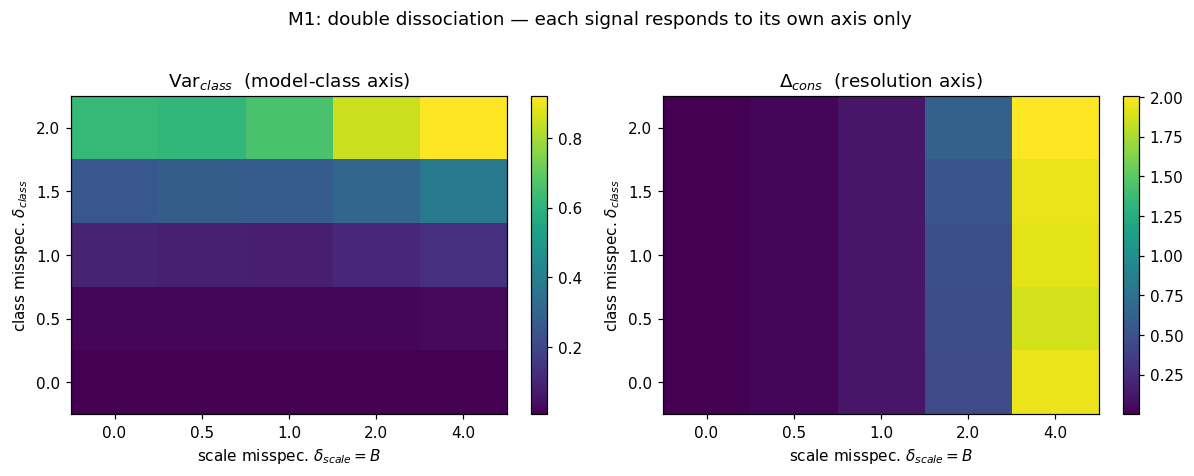

In [5]:
fig,ax=plt.subplots(1,2,figsize=(11,4.2))
for a,(Z,ttl) in zip(ax,[(VC,r'$\mathrm{Var}_{class}$  (model-class axis)'),(DC,r'$\Delta_{cons}$  (resolution axis)')]):
    im=a.imshow(Z,origin='lower',aspect='auto',cmap='viridis')
    a.set_xticks(range(len(BV))); a.set_xticklabels(BV); a.set_yticks(range(len(DCL))); a.set_yticklabels(DCL)
    a.set_xlabel(r'scale misspec. $\delta_{scale}=B$'); a.set_ylabel(r'class misspec. $\delta_{class}$')
    a.set_title(ttl); a.grid(False); fig.colorbar(im,ax=a,fraction=0.046)
fig.suptitle('M1: double dissociation — each signal responds to its own axis only',y=1.02)
plt.tight_layout(); save_fig(fig,'fig_M1_dissociation'); plt.show()

## 3. (M2) Scale-equilibrium recovers the intrinsic scale

With fine structure present ($B>0$), the held-out error as a function of resolution $K$ is U-shaped: coarse
representations miss the feature (bias), very fine ones fit noise (variance). The equilibrium scale $s^\star$ of the
MSIE objective is the minimiser; it should coincide with the intrinsic scale $K=F_0$.

[figure] Figures/fig_M2_equilibrium.png,.pdf


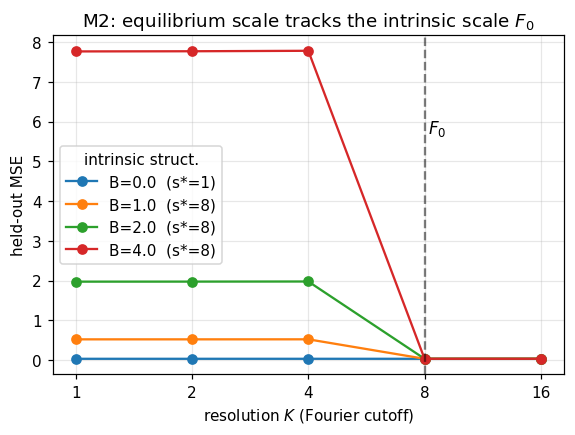

     B  s_star_recovered  MSE_K1  MSE_K2  MSE_K4  MSE_K8  MSE_K16
0  0.0                 1   0.030   0.030   0.030    0.03    0.031
1  1.0                 8   0.520   0.520   0.520    0.03    0.031
2  2.0                 8   1.972   1.973   1.976    0.03    0.031
3  4.0                 8   7.768   7.772   7.784    0.03    0.031
[table ] Tables/M2_equilibrium.csv
M2: intrinsic frequency F0=8; recovered s* at B>0 = [8, 8, 8]


In [6]:
def heldout_curve(B,seed=900):
    Xtr,ytr=sample(3000,0.0,B,np.random.default_rng(seed)); Xv,yv=sample(1500,0.0,B,np.random.default_rng(seed+1))
    errs=[]
    for K in SCALES_K:
        # consensus over classes at this scale
        preds=np.mean([Ridge(1.0).fit(feats(Xtr,K,m),ytr).predict(feats(Xv,K,m)) for m in CLASSES],axis=0)
        errs.append(np.mean((preds-yv)**2))
    return np.array(errs)

rows=[]; fig,ax=plt.subplots(figsize=(6,4))
for B in [0.0,1.0,2.0,4.0]:
    e=heldout_curve(B); kstar=SCALES_K[int(np.argmin(e))]
    ax.plot(SCALES_K,e,marker='o',label=f'B={B}  (s*={kstar})'); rows.append([B,kstar]+list(e))
ax.axvline(F0,ls='--',color='k',alpha=0.5); ax.text(F0*1.02,ax.get_ylim()[1]*0.7,r'$F_0$',fontsize=11)
ax.set_xscale('log',base=2); ax.set_xticks(SCALES_K); ax.set_xticklabels(SCALES_K)
ax.set_xlabel('resolution $K$ (Fourier cutoff)'); ax.set_ylabel('held-out MSE'); ax.legend(title='intrinsic struct.')
ax.set_title('M2: equilibrium scale tracks the intrinsic scale $F_0$')
save_fig(fig,'fig_M2_equilibrium'); plt.show()
dfEq=pd.DataFrame(rows,columns=['B','s_star_recovered']+[f'MSE_K{K}' for K in SCALES_K])
print(dfEq.round(3)); save_table(dfEq,'M2_equilibrium',index=False)
log(f'M2: intrinsic frequency F0={F0:.0f}; recovered s* at B>0 = '
    f'{[r[1] for r in rows if r[0]>0]}')

## 4. (M3) Decision value and the regime alarm

**Task.** Asymmetric reserve-type cost $L(a,y)=c_u(y-a)_+ + c_o(a-y)_+$, $c_u/c_o=5$. All policies commit the
multi-scale consensus $\bar f$, hedged by total uncertainty; they differ only in the **abstention signal**:

* **Class-only** ($\eta_s=0$) ranks deferral by $\mathrm{Var}_{\mathrm{class}}$ — the single-axis policy validated
  previously, blind to the resolution axis.
* **Two-axis** uses $\mathrm{Var}_{\mathrm{class}}$ per point and treats the window-aggregate
  $\bar\Delta_{\mathrm{cons}}$ as a **regime alarm**: when it exceeds a calibrated multiple of its in-distribution
  level, scale misspecification is present and the per-point deferral is driven by $\Delta_{\mathrm{cons}}$.

We report the scale-dominated regime (where class-only is blind), the class-dominated regime (where the two
coincide — the empirical reduction), and the window-aggregate $\bar\Delta_{\mathrm{cons}}$ as a function of $B$.

In [7]:
CU,CO=5.0,1.0; ZT=norm.ppf(CU/(CU+CO)); COV=np.linspace(0.5,1.0,26)
def acost(a,y): return CU*np.maximum(y-a,0)+CO*np.maximum(a-y,0)
def selcurve(cost,sig):
    o=np.argsort(sig); cs=cost[o]; return np.array([cs[:max(1,int(c*len(cost)))].mean() for c in COV])

# in-distribution baseline for the Delta_cons regime alarm
Xb,yb=sample(3000,0.0,0.0,np.random.default_rng(42)); Gb=fit_grid(Xb,yb)
_,_,_,vs0,_=twoway(predict_grid(Gb,sample(800,0.0,0.0,np.random.default_rng(5))[0])); DC0=vs0.mean()+1e-9

def policies(dc,B,seed=11):
    Xtr,ytr=sample(3000,0.0,B,np.random.default_rng(42)); G=fit_grid(Xtr,ytr)
    Xte,yte=sample(800,dc,B,np.random.default_rng(seed)); grand,vw,vc,vs,vi=twoway(predict_grid(G,Xte))
    sig_e=np.std(yte-grand); a=grand+ZT*np.sqrt(sig_e**2+vc+vs); cost=acost(a,yte)
    alarm = vs.mean()/DC0 > 2.0                    # window-level regime alarm
    rc_erm=selcurve(cost,np.zeros_like(vc))
    rc_cls=selcurve(cost,vc)
    rc_two=selcurve(cost, vs if alarm else vc)     # regime-gated per-point signal
    i80=np.argmin(abs(COV-0.8))
    return dict(cost_erm=rc_erm[i80],cost_cls=rc_cls[i80],cost_two=rc_two[i80],
                dcbar=vs.mean(),vcbar=vc.mean(),alarm=int(alarm),
                rc_erm=rc_erm,rc_cls=rc_cls,rc_two=rc_two)

R_scale=policies(0.0,4.0); R_class=policies(2.0,0.0); R_benign=policies(0.0,0.0)
dec=pd.DataFrame([
  ['benign (dcl=0,B=0)',R_benign['cost_erm'],R_benign['cost_cls'],R_benign['cost_two'],R_benign['alarm']],
  ['class-dominated (dcl=2,B=0)',R_class['cost_erm'],R_class['cost_cls'],R_class['cost_two'],R_class['alarm']],
  ['scale-dominated (dcl=0,B=4)',R_scale['cost_erm'],R_scale['cost_cls'],R_scale['cost_two'],R_scale['alarm']],
],columns=['regime','ERM','class-only','two-axis','Dcons alarm'])
print(dec.round(3)); save_table(dec,'M3_decision_by_regime',index=False)

                        regime    ERM  class-only  two-axis  Dcons alarm
0           benign (dcl=0,B=0)  0.259       0.240     0.240            0
1  class-dominated (dcl=2,B=0)  0.862       0.561     0.561            0
2  scale-dominated (dcl=0,B=4)  2.099       2.142     1.974            1
[table ] Tables/M3_decision_by_regime.csv


     B  mean_Delta_cons  alarm_ratio_vs_indist
0  0.0            0.000                  1.096
1  0.5            0.032                435.114
2  1.0            0.129               1739.310
3  2.0            0.517               6958.240
4  4.0            2.067              27838.248
[table ] Tables/M3_regime_alarm.csv


[figure] Figures/fig_M3_decision.png,.pdf


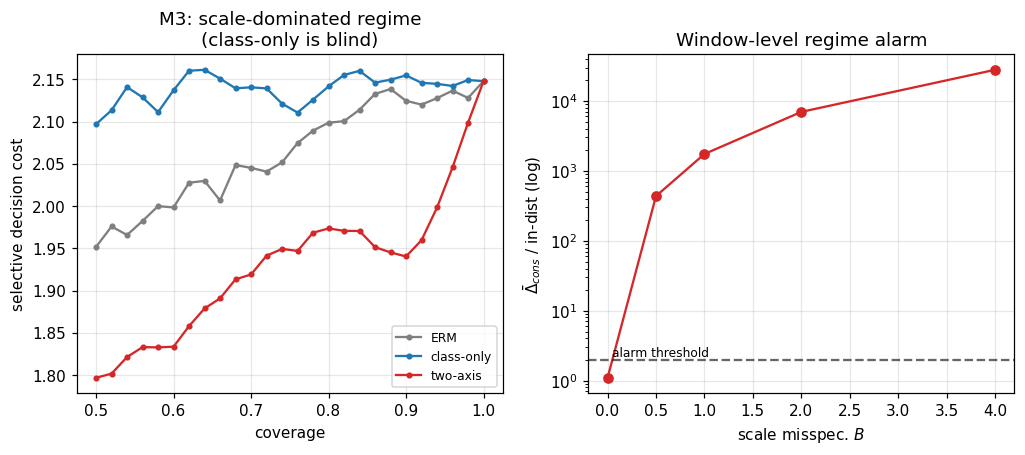

In [8]:
# Delta_cons window aggregate as a regime alarm: monotone in B, flat in delta_class
alarm_rows=[]
for B in [0.0,0.5,1.0,2.0,4.0]:
    Xtr,ytr=sample(3000,0.0,B,np.random.default_rng(42)); G=fit_grid(Xtr,ytr)
    dcb=[]; vcb=[]
    for dc in [0.0,1.0,2.0]:
        _,_,vc,vs,_=twoway(predict_grid(G,sample(600,dc,B,np.random.default_rng(13))[0]))
        dcb.append(vs.mean()); vcb.append(vc.mean())
    alarm_rows.append([B,np.mean(dcb),np.mean(dcb)/DC0])
dfAlarm=pd.DataFrame(alarm_rows,columns=['B','mean_Delta_cons','alarm_ratio_vs_indist'])
print(dfAlarm.round(3)); save_table(dfAlarm,'M3_regime_alarm',index=False)

fig,ax=plt.subplots(1,2,figsize=(11,4))
for nm,R,c in [('ERM','rc_erm','tab:gray'),('class-only','rc_cls','tab:blue'),('two-axis','rc_two','tab:red')]:
    ax[0].plot(COV,R_scale[R],marker='.',color=c,label=nm)
ax[0].set_xlabel('coverage'); ax[0].set_ylabel('selective decision cost')
ax[0].set_title('M3: scale-dominated regime\n(class-only is blind)'); ax[0].legend(fontsize=8)
ax[1].semilogy(dfAlarm['B'],dfAlarm['alarm_ratio_vs_indist'],marker='o',color='tab:red')
ax[1].axhline(2.0,ls='--',color='k',alpha=0.6); ax[1].text(0.05,2.2,'alarm threshold',fontsize=8)
ax[1].set_xlabel(r'scale misspec. $B$'); ax[1].set_ylabel(r'$\bar\Delta_{cons}$ / in-dist (log)')
ax[1].set_title('Window-level regime alarm'); save_fig(fig,'fig_M3_decision'); plt.show()

## 5. Export summary, `outputs_summary.tex`, and log to Drive

In [9]:
i80=np.argmin(abs(COV-0.8))
log('='*60); log('HEADLINE'); log('='*60)
log(f"M1 dissociation: Var_class explained by delta_class={diss.loc['Var_class','explained by delta_class']:.2f}, "
    f"by B={diss.loc['Var_class','explained by B (scale)']:.2f}")
log(f"                 Delta_cons explained by delta_class={diss.loc['Delta_cons','explained by delta_class']:.2f}, "
    f"by B={diss.loc['Delta_cons','explained by B (scale)']:.2f}")
log(f"M2 equilibrium recovers s*={SCALES_K[int(np.argmin(heldout_curve(2.0)))]} at B=2 (intrinsic F0={F0:.0f})")
log(f"M3 scale-dominated cost@80%: ERM={R_scale['cost_erm']:.3f} class-only={R_scale['cost_cls']:.3f} "
    f"two-axis={R_scale['cost_two']:.3f}")
log(f"M3 class-dominated (reduction): class-only={R_class['cost_cls']:.3f} two-axis={R_class['cost_two']:.3f}")
log(f"M3 regime alarm ratio at B=4: {dfAlarm['alarm_ratio_vs_indist'].iloc[-1]:.0f}x in-distribution")

def f3(x): return f'{x:.3f}'
tex=[]
tex.append(r'% outputs_summary.tex -- MSIE validation, auto-generated by the companion notebook.')
tex.append(r'% Requires \usepackage{booktabs,graphicx} and \graphicspath{{Figures/}}.')
tex.append(r'\begin{table}[t]\centering')
tex.append(r'\caption{Double dissociation (M1): fraction of between-cell variance ($\eta^2$) of each disagreement '
           r'signal attributable to model-class misspecification ($\delta_{\mathrm{class}}$) versus scale '
           r'misspecification ($B$). Each signal is explained almost entirely by its own axis.}')
tex.append(r'\label{tab:msie-dissociation}\begin{tabular}{lcc}\toprule')
tex.append(r'Signal & by $\delta_{\mathrm{class}}$ & by $B$ (scale) \\ \midrule')
tex.append(rf"$\mathrm{{Var}}_{{\mathrm{{class}}}}$ & {f3(diss.loc['Var_class','explained by delta_class'])} & {f3(diss.loc['Var_class','explained by B (scale)'])} \\")
tex.append(rf"$\Delta_{{\mathrm{{cons}}}}$ & {f3(diss.loc['Delta_cons','explained by delta_class'])} & {f3(diss.loc['Delta_cons','explained by B (scale)'])} \\")
tex.append(r'\bottomrule\end{tabular}\end{table}')
tex.append('')
tex.append(r'\begin{table}[t]\centering')
tex.append(r'\caption{Decision cost at 80\% coverage by regime (M3). In the scale-dominated regime the two-axis '
           r'policy improves on the class-only (single-axis) policy, which is blind to resolution misspecification; '
           r'in the class-dominated regime the two coincide (empirical reduction).}')
tex.append(r'\label{tab:msie-decision}\begin{tabular}{lccc}\toprule')
tex.append(r'Regime & ERM & class-only & two-axis \\ \midrule')
for _,r in dec.iterrows():
    tex.append(rf"{r['regime']} & {f3(r['ERM'])} & {f3(r['class-only'])} & {f3(r['two-axis'])} \\")
tex.append(r'\bottomrule\end{tabular}\end{table}')
tex.append('')
for fn,cap,lab in [('fig_M1_dissociation',
    r'Double dissociation (M1). $\mathrm{Var}_{\mathrm{class}}$ (left) varies only with model-class '
    r'misspecification $\delta_{\mathrm{class}}$; $\Delta_{\mathrm{cons}}$ (right) varies only with scale '
    r'misspecification $B$. The resolution axis detects a failure mode invisible to the class axis.','fig:msie-diss'),
   ('fig_M2_equilibrium',
    r'Scale-equilibrium recovery (M2). Held-out error is U-shaped in resolution and minimised at the intrinsic '
    r'scale $F_0$; the MSIE equilibrium $s^\star$ recovers it.','fig:msie-eq'),
   ('fig_M3_decision',
    r'Decision value and regime alarm (M3). Left: risk--coverage in the scale-dominated regime; the two-axis '
    r'policy lies below the class-only policy, which is blind. Right: the window aggregate $\bar\Delta_{\mathrm{cons}}$ '
    r'rises with $B$, acting as a regime alarm.','fig:msie-dec')]:
    tex.append(r'\begin{figure}[t]\centering\includegraphics[width=\columnwidth]{%s.pdf}' % fn)
    tex.append(r'\caption{%s}\label{%s}\end{figure}' % (cap,lab)); tex.append('')
open(os.path.join(OUTPUT_DIR,'outputs_summary.tex'),'w').write('\n'.join(tex))
log('[tex   ] outputs_summary.tex')
open(os.path.join(OUTPUT_DIR,'output_summary.txt'),'w').write(
    'MSIE / Multi-Scale Information Equilibrium - validation\n'+'='*60+'\n\n'+'\n'.join(_LOG))
print('\nArtifacts under',OUTPUT_DIR)
for root,_,fs in os.walk(OUTPUT_DIR):
    for fn in sorted(fs): print('  ',os.path.relpath(os.path.join(root,fn),OUTPUT_DIR))
log(f'runtime {time.time()-t0:.0f}s')

HEADLINE
M1 dissociation: Var_class explained by delta_class=0.95, by B=0.02
                 Delta_cons explained by delta_class=0.00, by B=1.00
M2 equilibrium recovers s*=8 at B=2 (intrinsic F0=8)
M3 scale-dominated cost@80%: ERM=2.099 class-only=2.142 two-axis=1.974
M3 class-dominated (reduction): class-only=0.561 two-axis=0.561
M3 regime alarm ratio at B=4: 27838x in-distribution
[tex   ] outputs_summary.tex

Artifacts under /root/Outputs/MSIE
   output_summary.txt
   outputs_summary.tex
   Figures/fig_M1_dissociation.pdf
   Figures/fig_M1_dissociation.png
   Figures/fig_M2_equilibrium.pdf
   Figures/fig_M2_equilibrium.png
   Figures/fig_M3_decision.pdf
   Figures/fig_M3_decision.png
   Tables/M1_delta_cons_grid.csv
   Tables/M1_dissociation_eta2.csv
   Tables/M1_var_class_grid.csv
   Tables/M2_equilibrium.csv
   Tables/M3_decision_by_regime.csv
   Tables/M3_regime_alarm.csv
runtime 10s
